# 02 -- Training (dua fase, resume-safe)

Melatih satu backbone ConvNeXt per run notebook ini (ganti `BACKBONE` di
sel konfigurasi, jalankan lagi untuk backbone lain -- BUKAN 4 notebook
terpisah seperti eksperimen lama, supaya tidak ada copy-paste bug lagi).

**Prasyarat (wajib sebelum jalan):**
1. `results/split_manifest.json` sudah ada (dari `01_dataset_audit.ipynb`
   + resplit -- gerbang audit GAGAL 34.84% kebocoran, split lama dari
   Kaggle TIDAK dipakai lagi).
2. Dataset ada di `/content/drive/MyDrive/Bone_Fracture_Dataset` (struktur
   sama seperti lokal -- manifest pakai path RELATIF, jadi portable).
3. Repo `project-fracture` accessible dari Colab (public di GitHub) --
   sel berikutnya clone otomatis.

**Resume:** kalau sesi Colab terputus, jalankan ulang notebook ini dari
atas dengan `BACKBONE` yang sama -- `src/fracture/train.py` baca
`status.json` di `runs/<run_id>/` dan lanjut dari epoch terakhir yang
benar-benar tersimpan, TIDAK mengulang dari ImageNet weights.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Konfigurasi -- SATU-SATUNYA baris yang perlu diganti per run

In [ ]:
BACKBONE = "small"  # ganti ke "tiny" / "small" / "base" / "large"

DATASET_ROOT = "/content/drive/MyDrive/project-fracture/dataset/Bone_Fracture_Dataset"  # sesuai path nyata di Drive-mu (dari run 01_dataset_audit.ipynb) -- GANTI kalau strukturmu beda
REPO_URL = "https://github.com/alianhar/project-fracture.git"
REPO_DIR = "/content/project-fracture"
RUNS_ROOT = "/content/drive/MyDrive/fracture-runs"  # di Drive -- selamat dari disconnect

In [3]:
import os
import shutil

def _is_valid_git_repo(path):
    return os.path.isdir(os.path.join(path, ".git"))

# Bersihkan sisa clone gagal dari percobaan sebelumnya (folder ada tapi
# bukan git repo valid) -- tanpa ini, run berikutnya masuk ke `git pull`
# di folder yang bukan repo dan gagal dengan error baru yang membingungkan.
if os.path.exists(REPO_DIR) and not _is_valid_git_repo(REPO_DIR):
    print(f"{REPO_DIR} ada tapi bukan git repo valid (sisa percobaan gagal) -- dihapus, clone ulang.")
    shutil.rmtree(REPO_DIR)

if not os.path.exists(REPO_DIR):
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

# Gagal di sini secara EKSPLISIT kalau clone/pull tidak sukses -- supaya
# error jelas muncul di cell ini, bukan menyamar jadi ModuleNotFoundError
# yang membingungkan beberapa cell kemudian.
assert _is_valid_git_repo(REPO_DIR), (
    f"Clone/pull gagal -- {REPO_DIR} bukan git repo valid. "
    "Cek repo GitHub public & REPO_URL benar (lihat output !git di atas)."
)

import sys
sys.path.insert(0, REPO_DIR)

Cloning into '/content/project-fracture'...
remote: Enumerating objects: 178, done.
remote: Counting objects: 100% (178/178), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 178 (delta 7), reused 166 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (178/178), 2.18 MiB | 319.00 KiB/s, done.
Resolving deltas: 100% (7/7), done.


In [4]:
!pip -q install pyyaml

In [5]:
import json
import hashlib
from pathlib import Path

import yaml
import tensorflow as tf

from src.fracture.data import make_generators, compute_class_weight
from src.fracture.train import run_training

# Config terkunci + override backbone (spec Sec6.1) -- HANYA backbone yang
# beda antar model, seluruh hyperparameter lain identik.
with open(f"{REPO_DIR}/configs/base.yaml") as f:
    config = yaml.safe_load(f)

override_file = "base_model.yaml" if BACKBONE == "base" else f"{BACKBONE}.yaml"
with open(f"{REPO_DIR}/configs/{override_file}") as f:
    config.update(yaml.safe_load(f))

print(json.dumps(config, indent=2))

{
  "seed": 42,
  "img_size": 224,
  "batch_size": 16,
  "preprocessing": "convnext_native",
  "augment_train": {
    "rotation_range": 15,
    "zoom_range": 0.15,
    "horizontal_flip": true
  },
  "split_manifest": "results/split_manifest.json",
  "use_class_weight": true,
  "phase1": {
    "epochs": 30,
    "lr": 0.0001,
    "frozen": true
  },
  "phase2": {
    "epochs": 40,
    "lr": 1e-05,
    "unfreeze_last_stages": 2
  },
  "callbacks": {
    "early_stopping": {
      "monitor": "val_loss",
      "patience": 8,
      "restore_best_weights": true
    },
    "reduce_lr": {
      "monitor": "val_loss",
      "patience": 4,
      "factor": 0.5
    },
    "checkpoint": {
      "save_best_only": true
    }
  },
  "backbone": "small"
}


In [6]:
tf.keras.utils.set_random_seed(config["seed"])  # fix R1: seed didefinisikan tapi tidak dipakai di eksperimen lama

# Hash config -- run_dir stabil untuk config yang sama (resume jalan lintas
# eksekusi notebook), tapi berubah otomatis kalau config diubah (jadi run
# baru, bukan tercampur dengan hasil config lama).
config_str = json.dumps(config, sort_keys=True)
config_hash = hashlib.sha256(config_str.encode()).hexdigest()[:8]
run_id = f"{BACKBONE}_{config_hash}"
run_dir = f"{RUNS_ROOT}/{run_id}"

print("run_id:", run_id)
print("run_dir:", run_dir)

run_id: small_4fdac66d
run_dir: /content/drive/MyDrive/fracture-runs/small_4fdac66d


## Data -- dari split_manifest.json, BUKAN struktur folder Kaggle asli

In [7]:
manifest_path = f"{REPO_DIR}/results/split_manifest.json"

train_gen, val_gen, test_gen = make_generators(
    manifest_path=manifest_path,
    dataset_root=DATASET_ROOT,
    img_size=config["img_size"],
    batch_size=config["batch_size"],
    seed=config["seed"],
    augment_train=config["augment_train"],
)

class_weight = compute_class_weight(manifest_path, DATASET_ROOT) if config["use_class_weight"] else None
print("class_indices:", train_gen.class_indices)
print("class_weight:", class_weight)
print(f"train={train_gen.samples}  val={val_gen.samples}  test={test_gen.samples}")

Found 2358 validated image filenames belonging to 2 classes.
Found 504 validated image filenames belonging to 2 classes.
Found 508 validated image filenames belonging to 2 classes.
class_indices: {'fractured': 0, 'not_fractured': 1}
class_weight: {0: np.float64(1.1993896236012207), 1: np.float64(0.8574545454545455)}
train=2358  val=504  test=508


## Training -- resume otomatis kalau run_dir sudah punya checkpoint

In [8]:
best_model_path = run_training(
    backbone_name=BACKBONE,
    train_gen=train_gen,
    val_gen=val_gen,
    class_weight=class_weight,
    run_dir=run_dir,
    config=config,
)
print("Model terbaik tersimpan di:", best_model_path)

[small] Resume: /content/drive/MyDrive/fracture-runs/small_4fdac66d/latest.keras (fase=phase1, epoch selesai=2)
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8618 - loss: 0.3679 

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


148/148 ━━━━━━━━━━━━━━━━━━━━ 2527s 17s/step - accuracy: 0.8643 - loss: 0.3583 - val_accuracy: 0.8631 - val_loss: 0.3557 - learning_rate: 1.0000e-04
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 54s 361ms/step - accuracy: 0.8736 - loss: 0.3241 - val_accuracy: 0.8770 - val_loss: 0.3036 - learning_rate: 1.0000e-04
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 54s 361ms/step - accuracy: 0.8838 - loss: 0.3025 - val_accuracy: 0.8849 - val_loss: 0.2796 - learning_rate: 1.0000e-04
Epoch 6/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 57s 387ms/step - accuracy: 0.9033 - loss: 0.2673 - val_accuracy: 0.9048 - val_loss: 0.2709 - learning_rate: 1.0000e-04
Epoch 7/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 56s 376ms/step - accuracy: 0.9025 - loss: 0.2455 - val_accuracy: 0.9167 - val_loss: 0.2539 - learning_rate: 1.0000e-04
Epoch 8/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 56s 382ms/step - accuracy: 0.9148 - loss: 0.2281 - val_accuracy: 0.9107 - val_loss: 0.2312 - learning_rate: 1.0000e-04
Epoch 9/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 55s 370ms/step - 

## Sanity check cepat di test set (evaluasi formal ada di 03_evaluate_export.ipynb)

In [9]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

model = tf.keras.models.load_model(best_model_path)

y_prob = model.predict(test_gen, steps=len(test_gen), verbose=1).ravel()
y_true = test_gen.classes
y_pred = (y_prob >= 0.5).astype(int)

print("Accuracy (threshold 0.5, sanity check saja):", accuracy_score(y_true, y_pred))
print()
print(classification_report(y_true, y_pred, target_names=sorted(train_gen.class_indices, key=train_gen.class_indices.get), digits=4))

32/32 ━━━━━━━━━━━━━━━━━━━━ 421s 13s/step
Accuracy (threshold 0.5, sanity check saja): 0.9862204724409449

               precision    recall  f1-score   support

    fractured     0.9858    0.9811    0.9835       212
not_fractured     0.9865    0.9899    0.9882       296

     accuracy                         0.9862       508
    macro avg     0.9862    0.9855    0.9858       508
 weighted avg     0.9862    0.9862    0.9862       508



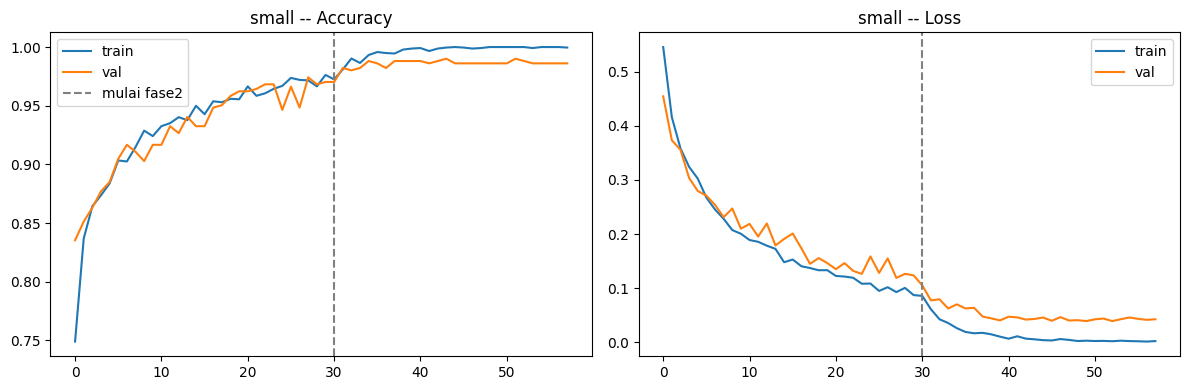

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

hist1 = pd.read_csv(f"{run_dir}/history_phase1.csv")
hist2 = pd.read_csv(f"{run_dir}/history_phase2.csv")
hist = pd.concat([hist1, hist2], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist["accuracy"], label="train")
axes[0].plot(hist["val_accuracy"], label="val")
axes[0].axvline(config["phase1"]["epochs"], color="gray", linestyle="--", label="mulai fase2")
axes[0].set_title(f"{BACKBONE} -- Accuracy")
axes[0].legend()

axes[1].plot(hist["loss"], label="train")
axes[1].plot(hist["val_loss"], label="val")
axes[1].axvline(config["phase1"]["epochs"], color="gray", linestyle="--")
axes[1].set_title(f"{BACKBONE} -- Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{run_dir}/training_curve.png", dpi=120)
plt.show()